# Naive RAG with LangChain + Gemini

A first, minimal **Retrieval-Augmented Generation** pipeline.

**Why RAG?** An LLM only knows what was in its training data. Ask it about `small.pdf` - VIT
University's FFCS (Fully Flexible Credit System) Academic Regulations 4.0 - and it guesses. RAG
fixes that at *query time*: retrieve relevant passages from the document, put them in the prompt,
and let the model answer from that supplied context.

**Naive** = the simplest version: one vector search, no query rewriting, no reranking (those are
the *Advanced RAG* notebook).

**Stack:** LLM `gemini-3.5-flash-lite` · embeddings `BAAI/bge-base-en-v1.5` (local) · vector store
Chroma (local) · framework LangChain (LCEL).

Runs on Colab/Kaggle, CPU is fine. Run the cells top to bottom.

## Install

Pinned to the LangChain 0.3 line (1.0 restructured several modules). If Colab shows a
"restart runtime" button after this cell, click it and re-run from the top.

In [ ]:
# pinned to the LangChain 0.3 line (1.0 restructured several modules)
!pip install -q "langchain>=0.3,<1.0" "langchain-core>=0.3,<1.0" "langchain-community>=0.3,<1.0" "langchain-text-splitters>=0.3,<1.0" "langchain-google-genai>=2.0,<3.0" "langchain-huggingface>=0.1,<1.0" "langchain-chroma>=0.1,<1.0" chromadb pypdf sentence-transformers


## Set your Gemini API key

Get a free key at https://aistudio.google.com/apikey. For a shared notebook, prefer loading it
from Colab/Kaggle **Secrets** rather than hard-coding it.

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"

# Part 1 - LLM vs Chat Model

Before the RAG chain, two LangChain basics.

- A **text (completion) LLM** takes a string and returns a string.
- A **chat model** takes a list of role-tagged messages (`system` / `human` / `ai`) and returns
  an `AIMessage`. Modern instruction-tuned models (Gemini, GPT-4, Claude, ...) are chat models.

`ChatGoogleGenerativeAI` is a chat model. Its raw output is an `AIMessage` object, so we usually
pipe it through `StrOutputParser()` to get a plain string.

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI

## Text-style call

`gemini-3.5-flash-lite` is a chat model, but you can still hand it a bare string. `max_tokens=50`
caps the reply. The prompt states a false premise on purpose - watch whether the model corrects it.

In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    max_tokens=50,
)

In [ ]:
llm.invoke("Answer in one word(yes or no). Cow's milk is green in color")

AIMessage(content='No', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': []}, id='run--01a06389-2759-70e3-8141-a2b96764c80d-0', usage_metadata={'input_tokens': 18, 'output_tokens': 1, 'total_tokens': 19, 'input_token_details': {'cache_read': 0}})

## Chat model call

Same class, no token cap. The return value is an `AIMessage`: the text lives in `.content`,
next to response metadata.

In [ ]:
chat_model = ChatGoogleGenerativeAI(model="gemini-3.5-flash-lite")

The next call returns a full `AIMessage` (text in `.content`), not a truncated string like the `max_tokens=50` LLM above.

In [ ]:
chat_model.invoke("Answer in detail. Cow's milk is green in color")

AIMessage(content='The statement **"cow’s milk is green in color"** is **false** under normal circumstances. Fresh, natural cow’s milk is white (or yellowish-white). \n\nHowever, in extremely rare, specific, and abnormal scenarios, milk can take on a greenish tint. To answer in detail, let’s break down why milk is normally white, what could possibly make it look green, and the science behind milk\'s coloration.\n\n---\n\n### 1. Why is normal cow’s milk white?\nMilk is an emulsion of water, fats, proteins, and carbohydrates (lactose). Its characteristic white color is primarily due to two factors:\n* **Casein Micelles:** Casein is the main protein in milk. These proteins clump together into microscopic particles called micelles. When light hits these micelles, it is scattered in all directions rather than passing straight through. Because all wavelengths of visible light are scattered equally, our eyes perceive the reflected light as white.\n* **Fat Globules:** Suspended fat droplets in

## Chat model output needs parsing

`StrOutputParser` extracts `.content` from the `AIMessage`. Piping `chat_model | StrOutputParser()`
gives a Runnable whose output is a plain string - the standard building block for every chain below.

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
simple_chain = chat_model | StrOutputParser()

In [ ]:
simple_chain.invoke("Answer in one word(yes or no). Cow's milk is green in color")

'No'

# Part 2 - A Naive RAG chain

**The pipeline:**

```
question
  -> retriever   (embed the question, search the vector store)  -> top-k chunks
  -> prompt      (system rules + chunks + question)
  -> chat model
  -> answer grounded in small.pdf
```

Steps 1-5 build this one piece at a time.

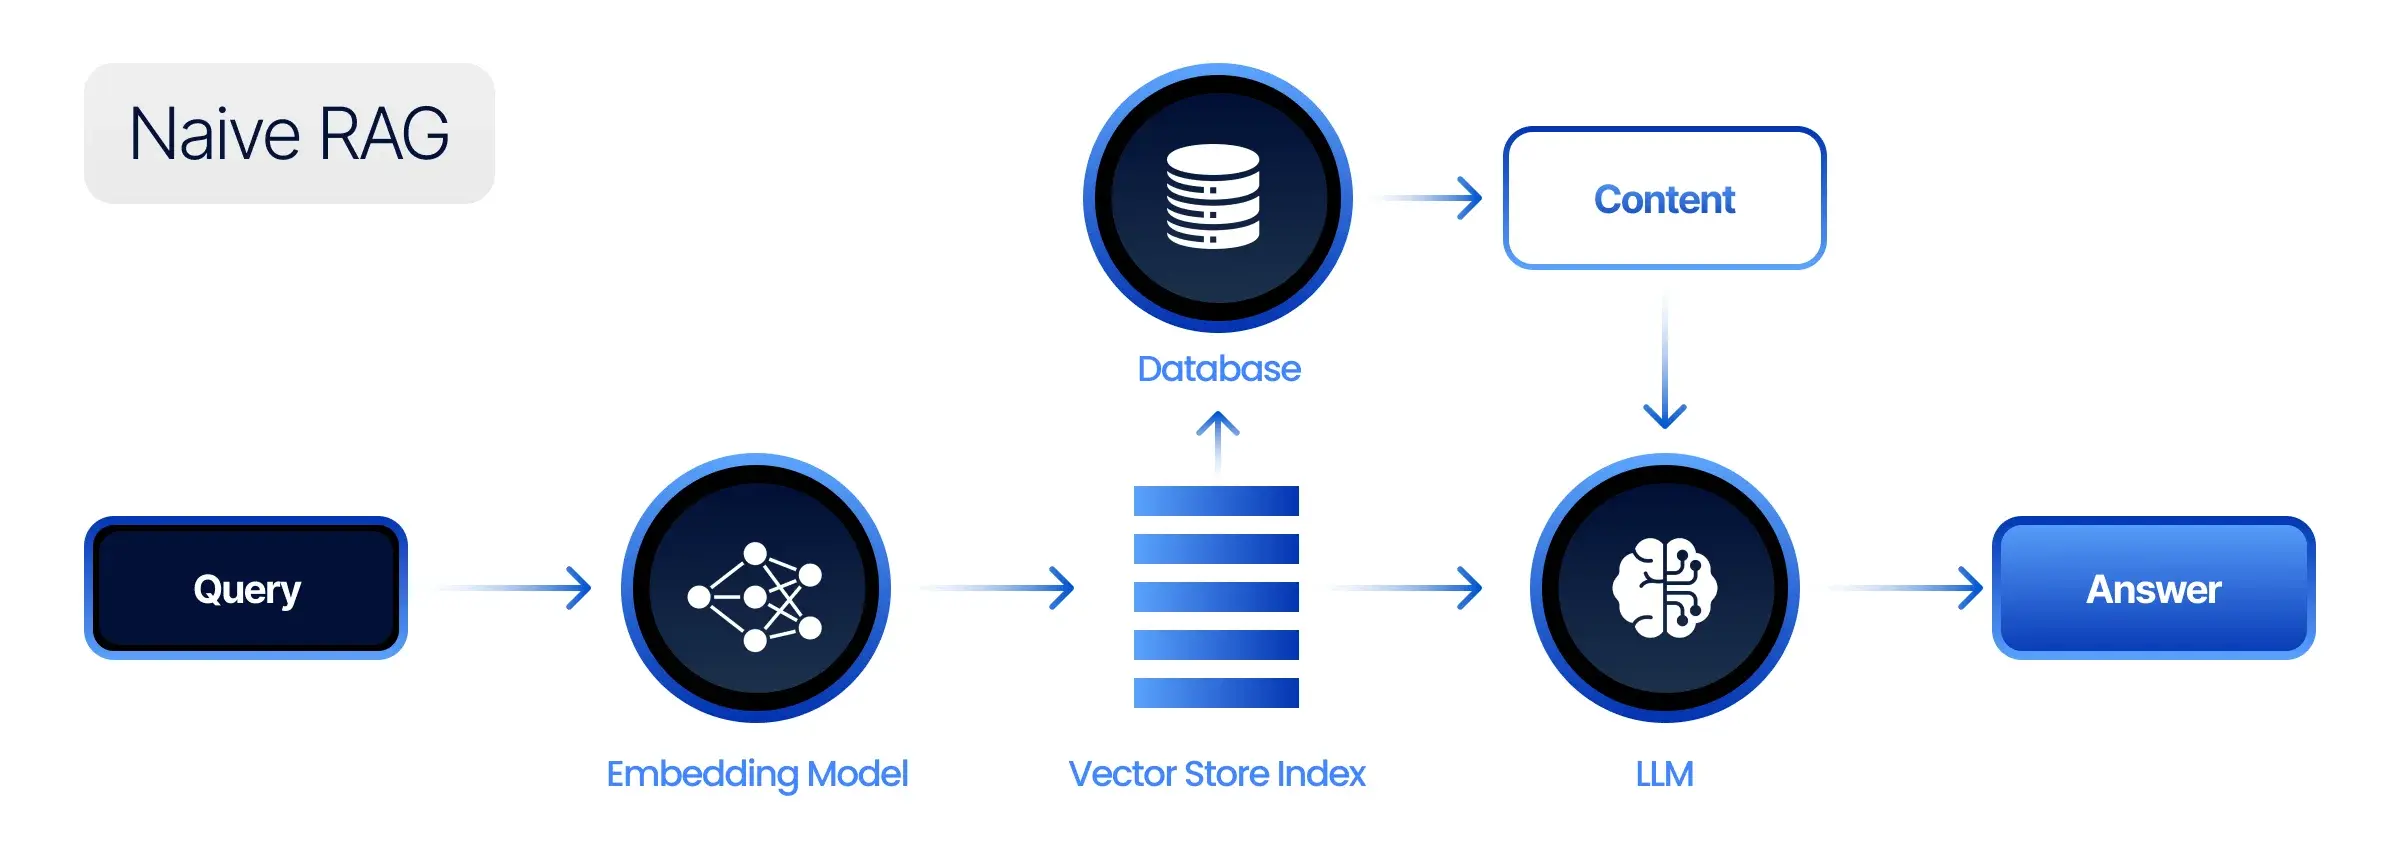

**Baseline (no RAG).** Ask the FFCS question with *no document supplied*. FFCS 4.0 details are
institution-specific, so expect a vague, generic, or partly wrong answer - the gap RAG closes.

In [ ]:
simple_chain.invoke("What is FFCS at VIT University and when was it introduced?")


'**FFCS** stands for **Fully Flexible Credit System**. It is one of the signature academic features of VIT (Vellore Institute of Technology). \n\nHere is a detailed breakdown of what it is and when it was introduced:\n\n### What is FFCS?\nUnlike traditional universities where students in a particular branch and year are assigned a fixed timetable and classroom, FFCS gives students the freedom to design their own timetable and academic path. \n\nKey features of FFCS include:\n*   **Choose Your Subjects:** Students can choose which courses/subjects they want to study in a particular semester, keeping prerequisites in mind.\n*   **Choose Your Professors:** During the course registration process, students can select the faculty member they want to learn from based on faculty ratings and teaching styles.\n*   **Choose Your Timings:** Students can build their own weekly timetables, deciding whether they want morning or afternoon classes, and which days they want off (subject to availability)

## Step 1 - Load the PDF

`PyPDFLoader` reads `small.pdf` into a list of `Document`s, one per page
(`.page_content` = text, `.metadata` = source + page number).

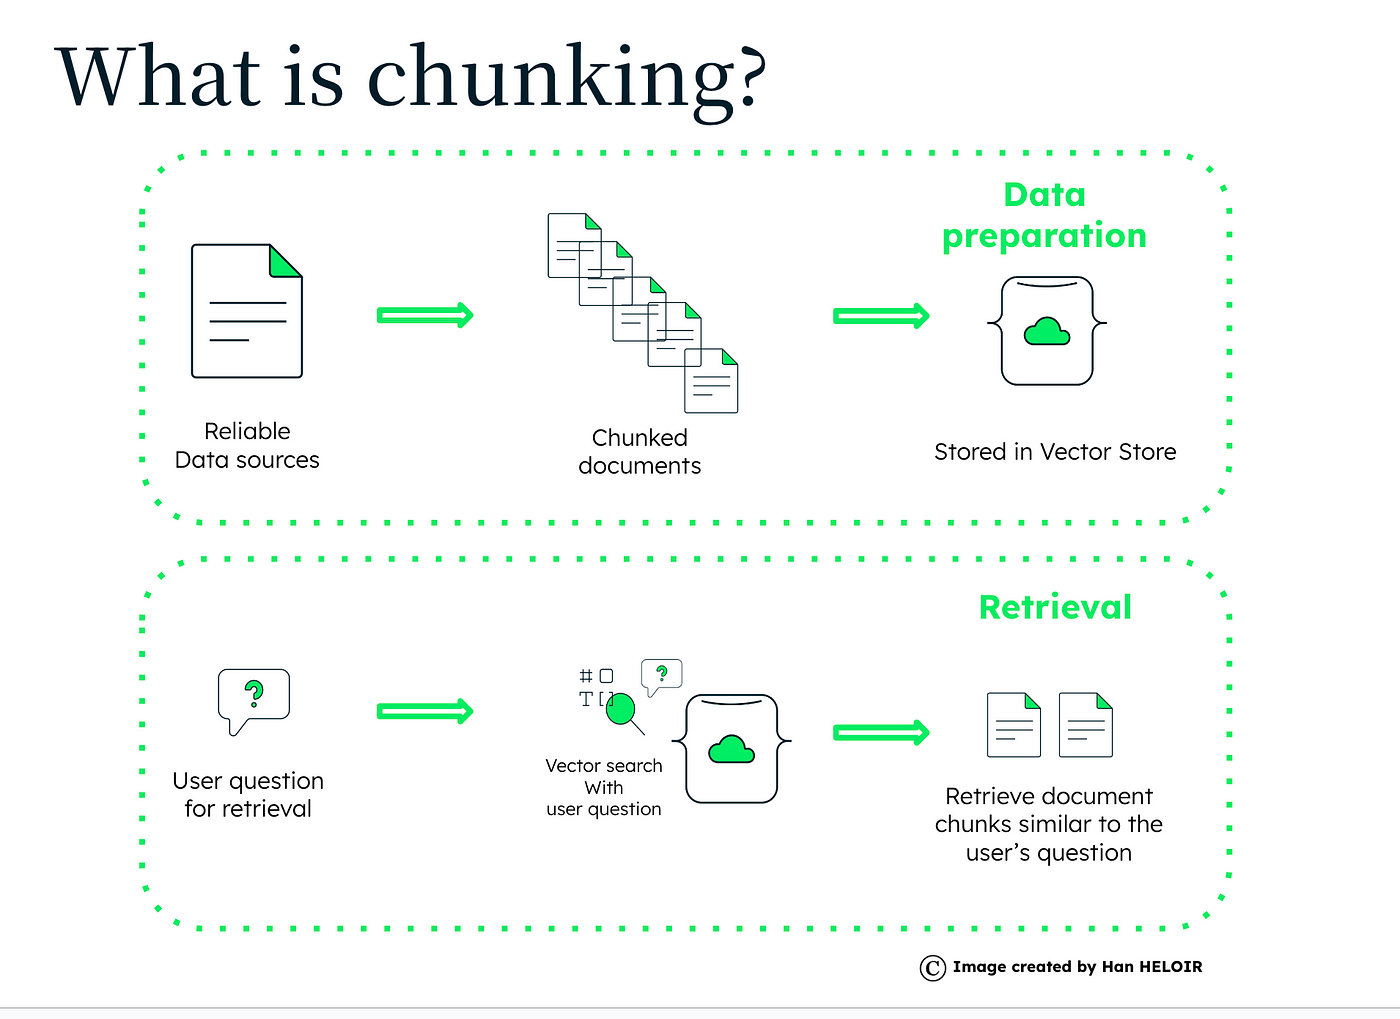

Set `PDF_PATH` to wherever `small.pdf` lives (Colab Files panel -> `/content/small.pdf`;
Kaggle -> `/kaggle/input/<slug>/small.pdf`).

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
import os

PDF_PATH = "/content/small.pdf"

print(os.path.exists(PDF_PATH))

True


In [ ]:
# small.pdf : a short write-up of VIT University's FFCS academic regulations
# Colab: upload it via the Files panel -> "/content/small.pdf"
PDF_PATH = "small.pdf"

import os
assert os.path.exists(PDF_PATH), f"PDF not found at {PDF_PATH!r} - upload small.pdf and fix PDF_PATH"

loader = PyPDFLoader(PDF_PATH)


In [ ]:
docs = loader.load()

In [ ]:
len(docs)

3

`len(docs)` = page count. `docs[1]` shows one page's `page_content` and `metadata`.

In [ ]:
docs[1]

Document(metadata={'producer': 'cairo 1.18.4 (https://cairographics.org)', 'creator': 'Mozilla Firefox 153.0.4', 'creationdate': '2026-09-02T14:54:53+05:30', 'source': 'small.pdf', 'total_pages': 3, 'page': 1, 'page_label': '2'}, page_content='which will help the student to develop additional skills.\n7. Important courses are offered in both semesters, which will help the students to re-\nregister the course and clear the backlog in the subsequent semester. This will help the\nslow learners.\n8. Provisions are there for academically sound students to carry out research activities\nin their UG Programme.\n9. FFCS offers not only wide choice of courses for students to build their own\ncurriculum, but also enhances their skill in planning.\n10. A Proctor / faculty advisor helps the student in identifying the courses to be\nstudied in each semester based on programme requirement, course prerequisites,\nstudent’s academic ability and interest in various disciplines, past academic history,\n

## Step 2 - Split into chunks

The retriever should hand the LLM *small, focused* passages, not whole pages.
`RecursiveCharacterTextSplitter` cuts on paragraph -> sentence -> word boundaries so chunks stay
readable, and `chunk_overlap` repeats a little text across each cut so a fact split between two
chunks still appears whole in one of them.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,     # small.pdf is only ~3 pages
    chunk_overlap=80,
)


`chunk_size=500` characters, `chunk_overlap=80`. Small = precise retrieval; the overlap protects
facts that straddle a boundary.

In [ ]:
chunks = text_splitter.split_documents(docs)

In [ ]:
len(chunks)

22

`chunks[5]`: still a `Document`, now a ~500-char slice that keeps the page metadata.

In [ ]:
chunks[5]


Document(metadata={'producer': 'cairo 1.18.4 (https://cairographics.org)', 'creator': 'Mozilla Firefox 153.0.4', 'creationdate': '2026-09-02T14:54:53+05:30', 'source': 'small.pdf', 'total_pages': 3, 'page': 0, 'page_label': '1'}, page_content='5. Students have the option of choosing courses from a ‘basket of courses’ that are\ngrouped into Foundation Core, Discipline Linked Engineering Courses, Discipline\nCore, Discipline Elective or Specialization Elective, Open Elective, Skill\nEnhancement Courses, Ability Enhancement Courses and Project and Internship.\n6. Students can choose courses from the other programmes (interdisciplinary courses)')

## Step 3 - Embed the chunks and index them in a vector store

**Embedding:** map text -> a fixed-length vector so that similar *meanings* land close together.
That is what lets the retriever match by meaning instead of keywords.

**Vector store:** holds those vectors and does fast nearest-neighbour search. Here it is a local
`chromadb` collection persisted to disk, wrapped by LangChain's `Chroma`.

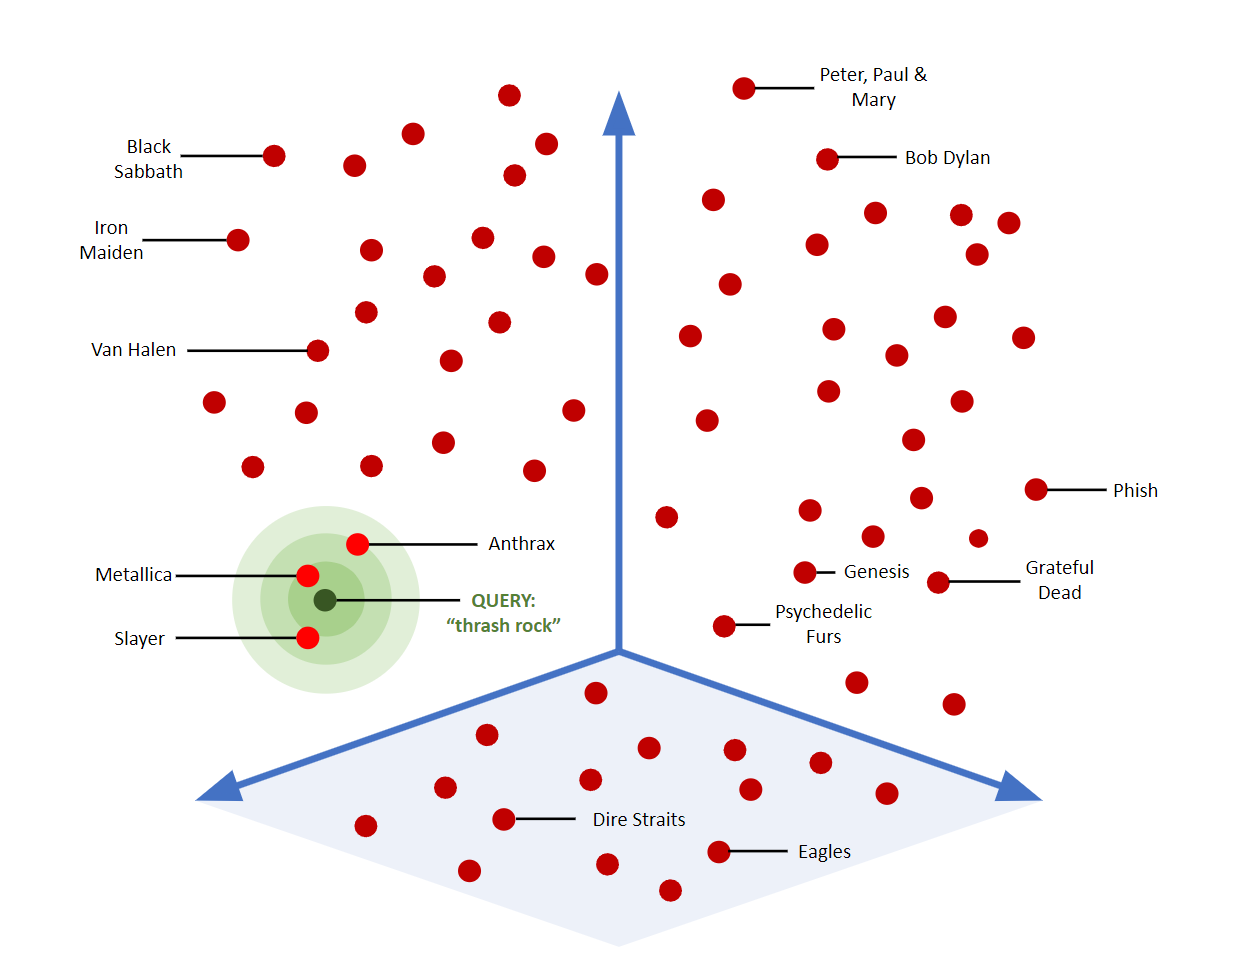

`BAAI/bge-base-en-v1.5` - a strong open embedding model, ~440 MB, runs locally on CPU.
The first call downloads the weights.

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

In [ ]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-base-en-v1.5")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

This same `embeddings` object is used now to index the chunks and later to embed each incoming question.

In [ ]:
import chromadb

In [ ]:
persistent_client = chromadb.PersistentClient(path="/content/vectorstore")

`PersistentClient` writes the index under `/content/vectorstore`, so it survives a kernel restart.

In [ ]:
persistent_client.get_or_create_collection("my_collection")

Collection(name=my_collection)

`get_or_create_collection` is idempotent - safe to re-run.

In [ ]:
from langchain_chroma import Chroma

Wrap the raw chroma collection in LangChain's `Chroma` so it accepts `Document`s and plugs into chains.

In [ ]:
vector_store_from_client = Chroma(
    client=persistent_client,
    collection_name="my_collection",
    embedding_function=embeddings,
)

In [ ]:
retriever = vector_store_from_client.as_retriever()

`as_retriever()` -> a `question -> top-k Document` component (default k = 4).

In [ ]:
retriever.add_documents(chunks)

['fe8adca0-3e19-4b26-9206-b6109c815cb6',
 '117f51b3-ee4d-415e-afd9-18a84f32da3a',
 'de68b79c-6ac0-498c-877b-042480ff9909',
 '664de258-e528-4a09-a6e0-300d90616d03',
 '27b48887-b58d-47a8-b387-20dcf0ca5224',
 '8328d03e-28ca-4fe7-8890-8ad5a4e0a4ef',
 '5e4974e8-42d7-46ec-9635-5a324a0161c5',
 '7cc68f54-7315-4756-8af1-f85385a33b0c',
 'd7c90677-c5b2-46fc-ae34-cf009b63a9f7',
 '18791a85-1be8-48a6-9095-dceeada9ef59',
 '0f080140-1fbe-4abb-8ec1-ae91b88ed68d',
 '6c224655-8803-43e8-81d2-1033527b8141',
 '47501dae-3f4a-4fb8-b4c2-33034035cbd9',
 '2125287e-b795-4e9c-83f5-fc5e63ab5e37',
 'c82488de-e8c1-466e-b6b4-0634c40fbf68',
 'ab6b79f1-7d58-4b89-91c3-82c92068209f',
 '087396a6-4e98-4dca-9543-59eb696ffe8b',
 'ca890ad4-9936-47bb-9ed2-d96caf0c7425',
 'ae52c24c-0af3-4263-8027-e5a07a0ada45',
 '5e389f4d-31a1-4290-8915-21183ef1b829',
 'fe20dc1c-aac1-4a54-9946-4c801c178664',
 '14567316-f828-4335-b516-ba58b37f3e32']

`add_documents(chunks)` embeds every chunk and stores its vector. The retriever is now live.

## Step 4 - The RAG prompt

A `ChatPromptTemplate` with two slots: `{query}` (the user's question) and `{context}` (the
retrieved chunks). The system message pins the model to that context.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
prompt = ChatPromptTemplate([
    ("system", """You are a helpful assistant designated
     to answer questions about VIT University's FFCS academic regulations document.
     Your name is Geeno."""),
    ("human", """
    Answer the following user question:
    {query}
    Here is some relevant context that might help you answer the question:
    {context}"""),
])


Two variables: `{query}` = the user's question, `{context}` = retrieved chunks. The chain fills both.

In [ ]:
prompt

ChatPromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="You are a helpful assistant designated\n     to answer questions about VIT University's FFCS academic regulations document.\n     Your name is Geeno."), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'query'], input_types={}, partial_variables={}, template='\n    Answer the following user question:\n    {query}\n    Here is some relevant context that might help you answer the question:\n    {context}'), additional_kwargs={})])

## Step 5 - Assemble the naive RAG chain

Wire the pieces together with LCEL (the `|` operator).Lang chain Expression Language

In [ ]:
from langchain_core.runnables import RunnableAssign, RunnableLambda

In [ ]:
def retrieve(state):
  query = state["query"]
  results = retriever.invoke(query)
  return " ".join([doc.page_content for doc in results])

`retrieve(state)` reads `state['query']`, runs the vector search, and returns the retrieved
chunk text joined into one string.

In [ ]:
chain = (RunnableAssign({"context":RunnableLambda(retrieve)}) |
         prompt |
         chat_model |
         StrOutputParser()
)

**Read left to right:** `RunnableAssign({'context': retrieve})` adds the retrieved text under
`context` -> `prompt` fills the template -> `chat_model` generates -> `StrOutputParser` -> string.
The chain's input is the dict `{'query': '...'}`.

In [ ]:
chain.invoke({"query":"What is FFCS at VIT and when did the university introduce it?"})


"Hello! I am Geeno, your assistant for VIT University's FFCS academic regulations. \n\nBased on the provided context, **FFCS** stands for **Fully Flexible Credit System**. \n\nRegarding when the university introduced it, the provided context does not mention the exact launch year of the overall FFCS system. However, it does note that separate regulations for VIT Business School were approved during the Standing Committee meeting of the Academic Council held on **24th September 2010**, and the current version of the regulations was approved in the 72nd Academic Council meeting. \n\nIf you have any more questions about the regulations, feel free to ask!"

The FFCS specifics in this answer came from `small.pdf`, not the model's memory.

In [ ]:
(chat_model|StrOutputParser()).invoke("What is FFCS at VIT and when did the university introduce it?")


"**FFCS** stands for **Fully Flexible Credit System**. It is one of the signature academic models of Vellore Institute of Technology (VIT). \n\nHere is a detailed breakdown of what it is and when it was introduced:\n\n---\n\n### What is FFCS?\n\nUnlike traditional universities where students in a particular branch study the exact same subjects in the same order, FFCS gives students the freedom to design their own timetable and curriculum to a large extent. \n\nKey features of FFCS include:\n\n1. **Choice of Subjects:** Students can choose which courses they want to study in a given semester, subject to meeting the prerequisites (e.g., passing a foundational course before taking an advanced one).\n2. **Choice of Faculty:** During the course registration process, students can view the names of the professors teaching different sections of a course and choose the faculty member whose teaching style or grading method they prefer.\n3. **Choice of Timings:** Students build their own weekly t

**Same question, no retrieval** - back to the vague pretrained answer. That gap is what RAG buys you.

# Evaluation of Simple RAG using RAGAS

RAGAS (Retrieval Augmented Generation Assessment) is used to evaluate
the quality of a RAG system.

In this notebook:

- Gemini is used for generating the RAG response.
- Gemini is also used as the judge/evaluator LLM.
- RAGAS is used to compute evaluation metrics such as:
  - Faithfulness
  - Response Relevancy
  - Context Precision

The existing Simple RAG pipeline is retained.
The evaluation starts after the final answer has been generated.

Install RAGAS and Ollama integration
Explanation

Your RAG already uses Ollama directly.

For evaluation, RAGAS needs an LLM interface. The easiest way to connect your local Ollama model to RAGAS is through langchain-ollama.

In [ ]:
# CELL 1: Install packages for LangChain + Gemini + RAGAS

!pip install -q \
    ragas \
    datasets \
    langchain \
    langchain-google-genai \
    langchain-chroma \
    langchain-text-splitters \
    chromadb \
    pypdf

In [ ]:
# CELL 2: Check package versions

import sys
import langchain
import ragas
import chromadb
import pypdf

print("Python       :", sys.version)
print("LangChain    :", langchain.__version__)
print("RAGAS        :", ragas.__version__)
print("ChromaDB     :", chromadb.__version__)
print("PyPDF        :", pypdf.__version__)

Python       : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
LangChain    : 0.3.30
RAGAS        : 0.4.3
ChromaDB     : 1.5.9
PyPDF        : 6.16.2


In [ ]:
# CELL 3: Test RAGAS and Gemini imports

from ragas import evaluate, EvaluationDataset
from ragas.dataset_schema import SingleTurnSample

# RAGAS metrics
from ragas.metrics import (
    Faithfulness,
    ResponseRelevancy,
    LLMContextPrecisionWithoutReference
)

# LangChain → RAGAS integration
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# LangChain → Gemini
from langchain_google_genai import ChatGoogleGenerativeAI

print("RAGAS imports      : OK")
print("Gemini import      : OK")
print("LangChain-RAGAS    : OK")

RAGAS imports      : OK
Gemini import      : OK
LangChain-RAGAS    : OK


/tmp/ipykernel_18565/2163770542.py:7: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/tmp/ipykernel_18565/2163770542.py:7: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import (
/tmp/ipykernel_18565/2163770542.py:7: DeprecationWarning: Importing LLMContextPrecisionWithoutReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithoutReference
  from ragas.metrics import (


In [ ]:
from google.colab import userdata

key = userdata.get("GOOGLE_API_KEY")

print("Secret found:", key is not None)

Secret found: True


In [ ]:
# CELL 4: Connect LangChain to Gemini

import os
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0
)

print("Gemini model created successfully.")

Gemini model created successfully.


In [ ]:
# CELL 5: Test Gemini

response = llm.invoke(
    "Answer in one word: Is the sky blue?"
)

print("Gemini response:", response.content)

Gemini response: Yes.


In [ ]:
# CELL 6: Load PDF

from langchain_community.document_loaders import PyPDFLoader

PDF_PATH = "/content/small.pdf"

loader = PyPDFLoader(PDF_PATH)
documents = loader.load()

print("Number of pages:", len(documents))
print("First page:")
print(documents[0].page_content[:1000])

Number of pages: 3
First page:
The following abbrevations are used in this document:
DLE means Discipline Linked Engineering Courses
DE means Discipline Elective
SE - Specialization Elective
OE means Open Elective
SEC means Skill Enhancement Courses
AEC means Ability Enhancement Courses
DC - Discipline Core
FC - Foundation core
LTPC - Lecture Tutorial Practical Credits
TH - Theory Only Courses
LO - Lab only courses
CO - Course Outcomes
FFCS - Fully Flexible Credit System
PBL - Project Based Learning
CAL - Curriculum for Applied Learning
ICT - Information and Communication Technology
VTOP - VIT on Top
This is a rewritten document about FFCS regulation 4.0 of VIT university. This
contains details about the programmes offered in the university. In this document
pertaining to academia, the terms "program" and "degree" are considered synonymous
and are used interchangeably.
Present day students like to make decisions on their own and like to plan their future
by themselves. Employers expect

In [ ]:
# CELL 7: Split documents into chunks

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80
)

chunks = text_splitter.split_documents(documents)

print("Number of pages :", len(documents))
print("Number of chunks:", len(chunks))

print("\nFirst chunk:")
print(chunks[0].page_content)

Number of pages : 3
Number of chunks: 22

First chunk:
The following abbrevations are used in this document:
DLE means Discipline Linked Engineering Courses
DE means Discipline Elective
SE - Specialization Elective
OE means Open Elective
SEC means Skill Enhancement Courses
AEC means Ability Enhancement Courses
DC - Discipline Core
FC - Foundation core
LTPC - Lecture Tutorial Practical Credits
TH - Theory Only Courses
LO - Lab only courses
CO - Course Outcomes
FFCS - Fully Flexible Credit System
PBL - Project Based Learning


In [ ]:
# CELL 8A: Install Hugging Face embedding support

!pip install -q sentence-transformers langchain-huggingface

In [ ]:
# CELL 8B: Create embeddings and Chroma vector store

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5"
)

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="ragas_demo"
)

print("Embeddings created successfully.")
print("Chroma vector store created successfully.")
print("Number of chunks stored:", len(chunks))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embeddings created successfully.
Chroma vector store created successfully.
Number of chunks stored: 22


In [ ]:
# CELL 9: Create the retriever

retriever = vectorstore.as_retriever(
    search_kwargs={"k": 3}
)

print("Retriever created successfully.")

Retriever created successfully.


In [ ]:
# CELL 10: Test retrieval

question = "What is the main topic discussed in the document?"

retrieved_docs = retriever.invoke(question)

print("Number of retrieved chunks:", len(retrieved_docs))

for i, doc in enumerate(retrieved_docs, start=1):
    print("\n" + "=" * 70)
    print(f"RETRIEVED CHUNK {i}")
    print("=" * 70)
    print(doc.page_content)
    print("\nMetadata:", doc.metadata)

Number of retrieved chunks: 3

RETRIEVED CHUNK 1
the University on issues dealt herein.
Not withstanding anything mentioned herein, the Academic Council (or) the
Academic Policy Committee headed by the Vice-Chancellor of the University has the
right to add, delete or modify these regulations time to time. In case of any dispute
arising in interpreting the rules, only the interpretation given by the Academic Council
(or) the Academic Policy Committee will be considered as final and binding.

Metadata: {'page': 1, 'page_label': '2', 'producer': 'cairo 1.18.4 (https://cairographics.org)', 'source': '/content/small.pdf', 'creationdate': '2026-09-02T14:54:53+05:30', 'total_pages': 3, 'creator': 'Mozilla Firefox 153.0.4'}

RETRIEVED CHUNK 2
The following abbrevations are used in this document:
DLE means Discipline Linked Engineering Courses
DE means Discipline Elective
SE - Specialization Elective
OE means Open Elective
SEC means Skill Enhancement Courses
AEC means Ability Enhancement Course

In [ ]:
# CELL 11: Build the RAG chain

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

prompt = ChatPromptTemplate.from_template("""
You are a helpful question-answering assistant.

Answer the question using ONLY the context provided below.

If the answer is not present in the context, say:
"I don't know based on the provided document."

Context:
{context}

Question:
{question}

Answer:
""")

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {
        "context": retriever | format_docs,
        "question": lambda x: x
    }
    | prompt
    | llm
    | StrOutputParser()
)

print("RAG chain created successfully.")

RAG chain created successfully.


In [ ]:
# CELL 12: Run the RAG pipeline

question = "What is FFCS?"

answer = rag_chain.invoke(question)

print("QUESTION:")
print(question)

print("\nANSWER:")
print(answer)

QUESTION:
What is FFCS?

ANSWER:
Based on the provided document, FFCS stands for Fully Flexible Credit System.


In [ ]:
# CELL 13: Prepare one RAG sample for RAGAS

question = "What is FFCS?"

# Retrieve the documents
retrieved_docs = retriever.invoke(question)

# Generate the answer
answer = rag_chain.invoke(question)

# Extract retrieved text
retrieved_contexts = [
    doc.page_content
    for doc in retrieved_docs
]

print("QUESTION:")
print(question)

print("\nANSWER:")
print(answer)

print("\nNUMBER OF RETRIEVED CONTEXTS:")
print(len(retrieved_contexts))

print("\nRETRIEVED CONTEXTS:")
for i, context in enumerate(retrieved_contexts, start=1):
    print(f"\n--- Context {i} ---")
    print(context)

QUESTION:
What is FFCS?

ANSWER:
Based on the provided document, FFCS stands for Fully Flexible Credit System.

NUMBER OF RETRIEVED CONTEXTS:
3

RETRIEVED CONTEXTS:

--- Context 1 ---
FFCS - Fully Flexible Credit System
PBL - Project Based Learning
CAL - Curriculum for Applied Learning
ICT - Information and Communication Technology
VTOP - VIT on Top
This is a rewritten document about FFCS regulation 4.0 of VIT university. This
contains details about the programmes offered in the university. In this document
pertaining to academia, the terms "program" and "degree" are considered synonymous
and are used interchangeably.

--- Context 2 ---
FFCS Regulations V ersion 2.00 was approved in 27th Academic Council meeting held
on 27th July 2012.
27th Academic Council meeting held on 27th July 2012.
FFCS Regulations V ersion 2.10 was approved in 28th Academic Council meeting held
on 15th August 2012. FFCS Regulations 3.0, which focussed on Curriculum on
Applied Learning (CAL), was approved in the

In [ ]:
# CELL 14: Connect Gemini to RAGAS

from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Wrap Gemini so RAGAS can use it as the evaluation LLM
ragas_llm = LangchainLLMWrapper(llm)

# Wrap our existing BGE embedding model
ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)

print("RAGAS LLM wrapper       : OK")
print("RAGAS embeddings wrapper: OK")

RAGAS LLM wrapper       : OK
RAGAS embeddings wrapper: OK


/tmp/ipykernel_18565/4160251630.py:7: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  ragas_llm = LangchainLLMWrapper(llm)
/tmp/ipykernel_18565/4160251630.py:10: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(embeddings)


In [ ]:
# CELL 15: Create a RAGAS evaluation sample

from ragas.dataset_schema import SingleTurnSample
from ragas import EvaluationDataset

# The question we already tested
question = "What is vit?"

# The RAG-generated answer
answer = rag_chain.invoke(question)

# Retrieve the same contexts used for this question
retrieved_docs = retriever.invoke(question)

# Convert Documents into plain text
retrieved_contexts = [
    doc.page_content
    for doc in retrieved_docs
]

# Create one RAGAS sample
sample = SingleTurnSample(
    user_input=question,
    response=answer,
    retrieved_contexts=retrieved_contexts
)

# Put the sample into an evaluation dataset
evaluation_dataset = EvaluationDataset(samples=[sample])

print("RAGAS evaluation sample created successfully.")

print("\nQuestion:")
print(sample.user_input)

print("\nAnswer:")
print(sample.response)

print("\nNumber of retrieved contexts:")
print(len(sample.retrieved_contexts))

RAGAS evaluation sample created successfully.

Question:
What is vit?

Answer:
I don't know based on the provided document.

Number of retrieved contexts:
3


In [ ]:
# CELL 16: Create RAGAS evaluation metrics

faithfulness = Faithfulness(
    llm=ragas_llm
)

response_relevancy = ResponseRelevancy(
    llm=ragas_llm,
    embeddings=ragas_embeddings
)

context_precision = LLMContextPrecisionWithoutReference(
    llm=ragas_llm
)

metrics = [
    faithfulness,
    response_relevancy,
    context_precision
]

print("RAGAS metrics created successfully.")
print("\nMetrics:")
print("1. Faithfulness")
print("2. Response Relevancy")
print("3. Context Precision")

RAGAS metrics created successfully.

Metrics:
1. Faithfulness
2. Response Relevancy
3. Context Precision


In [ ]:
# CELL 17: Run RAGAS evaluation

result = evaluate(
    dataset=evaluation_dataset,
    metrics=metrics
)

print("RAGAS evaluation completed successfully.")
print("\nEvaluation results:")
print(result)

Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

RAGAS evaluation completed successfully.

Evaluation results:
{'faithfulness': 0.0000, 'answer_relevancy': 0.0000, 'llm_context_precision_without_reference': 0.0000}


In [ ]:
# CELL 18: Create multiple RAGAS evaluation samples

questions = [
    "What is FFCS?",
    "What does DLE mean?",
    "What does PBL mean?",
    "What does VTOP mean?",
    "What does CAL mean?"
]

samples = []

for question in questions:

    # Retrieve relevant documents
    retrieved_docs = retriever.invoke(question)

    # Generate RAG answer
    answer = rag_chain.invoke(question)

    # Extract context text
    retrieved_contexts = [
        doc.page_content
        for doc in retrieved_docs
    ]

    # Create RAGAS sample
    sample = SingleTurnSample(
        user_input=question,
        response=answer,
        retrieved_contexts=retrieved_contexts
    )

    samples.append(sample)

# Create evaluation dataset
evaluation_dataset = EvaluationDataset(samples=samples)

print("Number of questions:", len(samples))

for i, sample in enumerate(samples, start=1):
    print("\n" + "=" * 60)
    print(f"QUESTION {i}")
    print("=" * 60)
    print("Question :", sample.user_input)
    print("Answer   :", sample.response)
    print("Contexts :", len(sample.retrieved_contexts))

Number of questions: 5

QUESTION 1
Question : What is FFCS?
Answer   : Based on the provided document, FFCS stands for Fully Flexible Credit System.
Contexts : 3

QUESTION 2
Question : What does DLE mean?
Answer   : DLE means Discipline Linked Engineering Courses
Contexts : 3

QUESTION 3
Question : What does PBL mean?
Answer   : Based on the provided document, PBL means Project Based Learning.
Contexts : 3

QUESTION 4
Question : What does VTOP mean?
Answer   : Based on the provided document, VTOP means "VIT on Top".
Contexts : 3

QUESTION 5
Question : What does CAL mean?
Answer   : Based on the provided document, CAL means Curriculum for Applied Learning.
Contexts : 3


In [ ]:
# CELL 19: Evaluate all 5 questions using RAGAS

result = evaluate(
    dataset=evaluation_dataset,
    metrics=metrics
)

print("RAGAS evaluation completed successfully.")
print("\nEvaluation results:")
print(result)

Evaluating:   0%|          | 0/15 [00:00<?, ?it/s]

* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite
Please retry in 32.07255147s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-3.5-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 15
}
, retry_delay {
  seconds: 32
}
].
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 15, model: gemini-3.5-flash-lite
Please retry in 31.865521116s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelangua

RAGAS evaluation completed successfully.

Evaluation results:
{'faithfulness': 1.0000, 'answer_relevancy': 0.9211, 'llm_context_precision_without_reference': 0.7667}


In [ ]:
# Convert RAGAS results to a DataFrame

results_df = result.to_pandas()

print("RAGAS Results:")
display(results_df)

RAGAS Results:


,user_input,retrieved_contexts,response,faithfulness,answer_relevancy,llm_context_precision_without_reference
0,What is FFCS?,[FFCS - Fully Flexible Credit System\nPBL - Pr...,"Based on the provided document, FFCS stands fo...",1.0,0.947719,1.000000
1,What does DLE mean?,[The following abbrevations are used in this d...,DLE means Discipline Linked Engineering Courses,1.0,0.944509,1.000000
2,What does PBL mean?,[The following abbrevations are used in this d...,"Based on the provided document, PBL means Proj...",1.0,1.000000,0.833333
3,What does VTOP mean?,[VTOP is the academic software of VIT. All sub...,"Based on the provided document, VTOP means ""VI...",1.0,0.951848,0.500000
4,What does CAL mean?,[The following abbrevations are used in this d...,"Based on the provided document, CAL means Curr...",1.0,0.761249,0.500000


In [ ]:
# Convert RAGAS result into a pandas DataFrame

results_df = result.to_pandas()

display(results_df)

,user_input,retrieved_contexts,response,faithfulness,answer_relevancy,llm_context_precision_without_reference
0,What is FFCS?,[FFCS - Fully Flexible Credit System\nPBL - Pr...,"Based on the provided document, FFCS stands fo...",1.0,0.947719,1.000000
1,What does DLE mean?,[The following abbrevations are used in this d...,DLE means Discipline Linked Engineering Courses,1.0,0.944509,1.000000
2,What does PBL mean?,[The following abbrevations are used in this d...,"Based on the provided document, PBL means Proj...",1.0,1.000000,0.833333
3,What does VTOP mean?,[VTOP is the academic software of VIT. All sub...,"Based on the provided document, VTOP means ""VI...",1.0,0.951848,0.500000
4,What does CAL mean?,[The following abbrevations are used in this d...,"Based on the provided document, CAL means Curr...",1.0,0.761249,0.500000


Average RAGAS Scores
------------------------------
Answer Relevancy    : 0.9211
Faithfulness        : 1.0000
Context Precision   : 0.7667


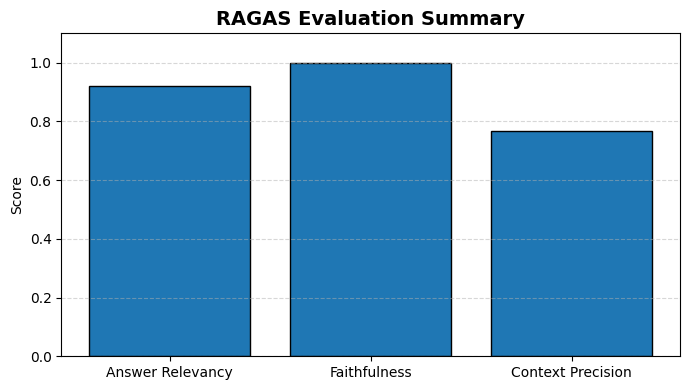

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute average score for each RAGAS metric
metrics = {
    "Answer Relevancy": np.nanmean(
        results_df["answer_relevancy"]
    ),
    "Faithfulness": np.nanmean(
        results_df["faithfulness"]
    ),
    "Context Precision": np.nanmean(
        results_df["llm_context_precision_without_reference"]
    )
}

# Print average scores
print("Average RAGAS Scores")
print("-" * 30)

for metric, score in metrics.items():
    print(f"{metric:20s}: {score:.4f}")

# Plot
plt.figure(figsize=(7, 4))

plt.bar(
    metrics.keys(),
    metrics.values(),
    edgecolor="black"
)

plt.title(
    "RAGAS Evaluation Summary",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("Score")
plt.ylim(0, 1.1)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

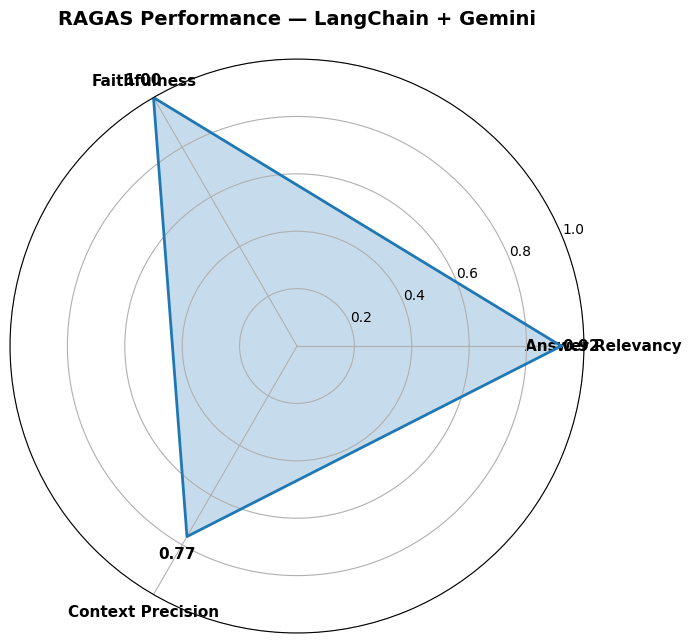

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- RAGAS metrics ---
labels = list(metrics.keys())
values = list(metrics.values())

# Close the radar chart
values_closed = values + values[:1]

# Calculate angles
angles = np.linspace(
    0,
    2 * np.pi,
    len(labels),
    endpoint=False
).tolist()

angles_closed = angles + angles[:1]

# --- Create radar chart ---
fig, ax = plt.subplots(
    figsize=(7, 7),
    subplot_kw=dict(polar=True)
)

# Plot
ax.plot(
    angles_closed,
    values_closed,
    linewidth=2
)

# Fill
ax.fill(
    angles_closed,
    values_closed,
    alpha=0.25
)

# Scale
ax.set_ylim(0, 1)

# Score rings
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(
    ["0.2", "0.4", "0.6", "0.8", "1.0"]
)

# Metric labels
ax.set_xticks(angles)
ax.set_xticklabels(
    labels,
    fontsize=11,
    fontweight="bold"
)

# Display score at each point
for angle, value in zip(angles, values):
    ax.text(
        angle,
        value + 0.07,
        f"{value:.2f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "RAGAS Performance — LangChain + Gemini",
    fontsize=14,
    fontweight="bold",
    pad=25
)

plt.tight_layout()
plt.show()